- Here we analyze how the structure function changes when modifying the 'Turbustat' versions for sysnthetic:
    - two-dimensional (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_extended.html#turbustat.simulator.make_extended)
    - and three-dimensional fields (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_3dfield.html#make-3dfield)
- Also, the recover the turbulent paramters throught a fit.


In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner
import ci_results_compiler


# Add path to py_modules 

sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot

In [3]:
# Physical parameters

N   = 512
m2D = 0.85 # for recovering m as 1.00 in the projected field
m3D_1 = 0.30 # for recovering m as 1.00 in the projected field
m3D_2 = 0.55 # for recovering m as 1.00 in the projected field
r0  = 32.0

# Fake velocity maps only

## Compare pure power law with tapered power law



The standard `make_extended()` function from `turbustat` gives a power law field (`vmap0`). 
I have modified it to use an exponential taper at large scales, which I use to make vmap (all other parameters are the same as `vmap0`).

# Modification

``` python
    if ellip < 1:
        # Apply a rotation and scale the x-axis (ellip).
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        xprime = ellip * (xx * costheta - yy * sintheta)
        yprime = xx * sintheta + yy * costheta

        rr2 = xprime ** 2 + yprime ** 2

        rr = rr2 ** 0.5
        # Also save circular version to use with correlation_length <-----------
        rcirc = np.hypot(xx, yy)   <-----------
        rcirc[rcirc == 0.0] = np.nan  <-----------
    else:
        # Circular whenever ellip == 1
        rr = (xx ** 2 + yy ** 2) ** 0.5

    # flag out the bad point to avoid warnings
    rr[rr == 0] = np.nan

    if correlation_length is not None:     <-----------
        # Taper the power spectrum at large separations (low spatial   <-----------
        # frequencies) so that the field is uncorrelated at the <-----------
        # largest scales. <-----------
        #
        # rcirc is spatial frequency: 1 / r, measured in pixels <-----------
        output *= np.exp(-1.0 / (2 * np.pi * rcirc * correlation_length)) <-----------
```


$$e^{-\dfrac{1}{2 \pi k r_0}}$$


In [4]:
# Tapered map
vmap = make_extended(
    N,
    powerlaw           = 2.0 + m2D,
    ellip              = 0.5,
    theta              = 45,
    correlation_length = r0,
    randomseed         = 1894_04_25,
)
signorm = vmap.std()
vmap /= signorm


# Non tapered map
vmap0 = make_extended(
    N,
    powerlaw      = 2.0 + m2D,
    ellip         = 0.5,
    theta         = 45,
    randomseed    = 1894_04_25,
)
signorm0 = vmap0.std()
vmap0 /= signorm0

signorm, signorm0

(1.8482080520449609, 4.349222322625375)

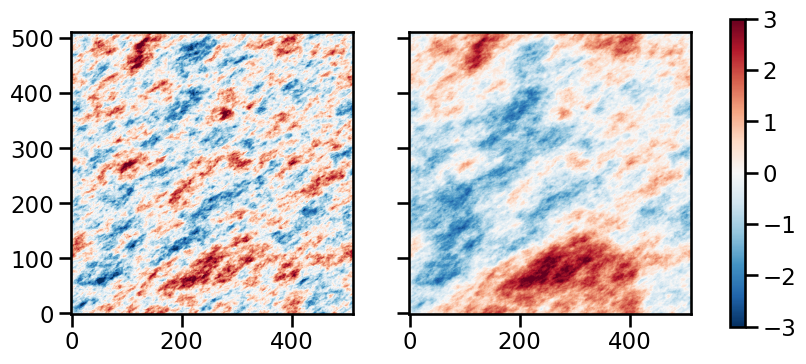

In [5]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap, **imshow_kwds)
im = axx.imshow(vmap0, **imshow_kwds)
fig.colorbar(im, ax=[ax, axx])

In [6]:
fftmap = make_extended(
    N,
    powerlaw=2.0 + m2D,
    ellip=0.5,
    theta=45,
    correlation_length=r0,
    randomseed=1894_04_25,
    return_fft=True,
)
fftmap0 = make_extended(
    N,
    powerlaw=2.0 + m2D,
    ellip=0.5,
    theta=45,
    randomseed=1894_04_25,
    return_fft=True,
)

pmap = np.real(fftmap * np.conj(fftmap))
pmap0 = np.real(fftmap0 * np.conj(fftmap0))

C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_20168\243268293.py:8: RuntimeWarning: divide by zero encountered in log10
  imm = axx.imshow(np.log10(pmap), **imshow_kwds)
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_20168\243268293.py:9: RuntimeWarning: invalid value encountered in divide
  im = ax.imshow((pmap / pmap0), cmap="gray_r", vmin=0.0, vmax=1.0)


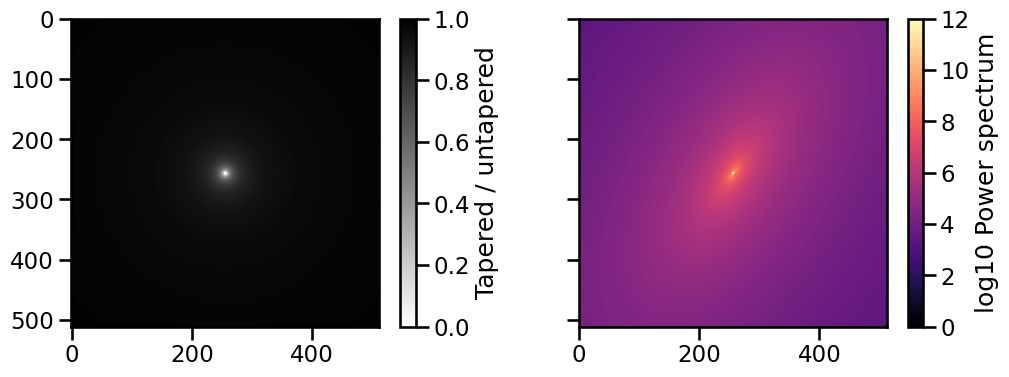

In [7]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 4),
)
imshow_kwds = dict(origin="lower", cmap="magma", vmin=0.0, vmax=12.0)
imm = axx.imshow(np.log10(pmap), **imshow_kwds)
im = ax.imshow((pmap / pmap0), cmap="gray_r", vmin=0.0, vmax=1.0)
fig.colorbar(im, ax=ax).set_label("Tapered / untapered")
fig.colorbar(imm, ax=axx).set_label("log10 Power spectrum")

## Structure function of fake velocity map tapered vs untapered

In [8]:
sf = strucfunc.strucfunc_numba_parallel(vmap, dlogr=0.05)
sf0 = strucfunc.strucfunc_numba_parallel(vmap0, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


[None, None, (0.008, 4)]

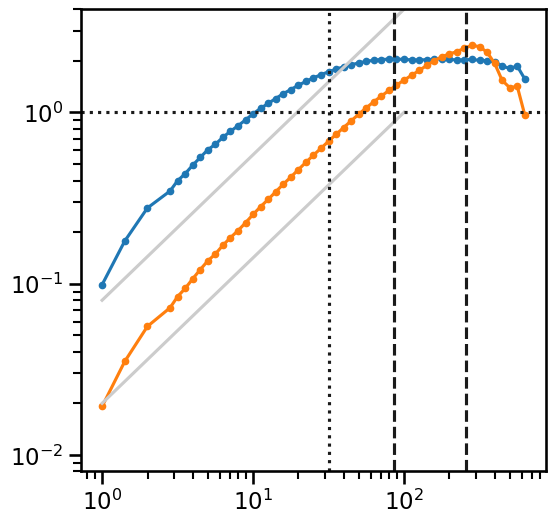

In [9]:
fig, ax = plt.subplots(
    figsize=(6, 6),
)
mask = sf["N pairs"] > 0
r = 10 ** sf["log10 r"][mask]
B = sf["Unweighted B(r)"][mask]
B0 = sf0["Unweighted B(r)"][mask]

ax.plot(r, B, marker=".")
ax.plot(r, B0, marker=".")

rgrid = np.logspace(0.0, 2.0)

for scale in 0.02, 0.08:
    ax.plot(rgrid, scale * rgrid ** m2D, color="0.8")

ax.axhline(1.0, color="k", linestyle="dotted")
ax.axvline(r0, color="k", linestyle="dotted")
ax.axvline(N / 2, color="k", linestyle="dashed")
ax.axvline(N / 6, color="k", linestyle="dashed")
ax.set(
    xscale="log",
    yscale="log",
    ylim=[8e-3, 4],
)

Note that:
- the untapered version (orange) has a good power law structure function that recovers m = 1.2 over a wide range of scales. But the tapered version (blue) flattens away from the power law quite quickly.
- Now that we are using a shallower power spectrum, we don't get the correlation length r0 to come out at exactly the tapering length that we fed in.
- The untapered structure function has a maximum at roughly half the box size and falls for larger scales. This is likely to be because of the periodic boundary conditions – we will investigate further below. Note that the derived r0 for the untapered version would be about 1/8 of the box size, but that this is not really a correlation length.

So we need a total field of view that is at least 8 times the correlation length in order to be able to recover the latter from the structure function


# Fake velocity cubes velocity and emissivity


- Generate simulated emissivity and velocity cubes
- Integrate them to get simulated intensity, velocity (and sigma) maps

## Sie E = 1

In [10]:
sig_E = 1 

In [11]:
# Non-Tapered
## Emissivity fluctuations


density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_1, 
#    correlation_length  = r0,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_1,
#    correlation_length = r0,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s  

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube0 = SpectralCube.read(cube_hdu)  

In [12]:
# Tapered
## Emissivity fluctuations

density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_1, 
    correlation_length  = r0,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_1,
    correlation_length = r0,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s   

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube = SpectralCube.read(cube_hdu)  

In [13]:
vmap_ = cube.moment1().value
vmap0_ = cube0.moment1().value

signorm_ = vmap_.std()
vmap_ /= signorm_

signorm0_ = vmap0_.std()
vmap0_ /= signorm0_

print(signorm_, signorm0_)

0.15674216075224537 0.33985318412446924


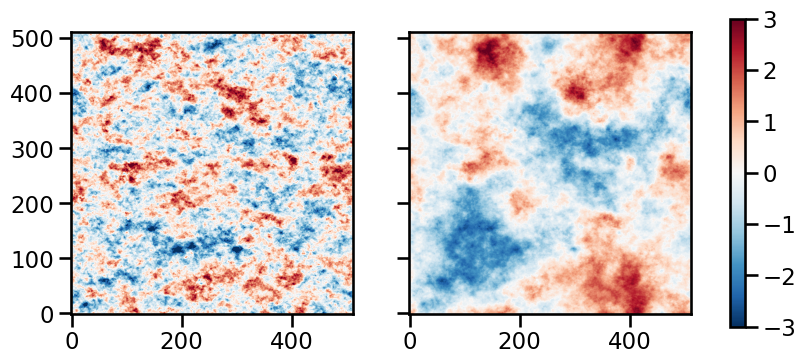

In [14]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap_, **imshow_kwds)
im = axx.imshow(vmap0_, **imshow_kwds)
fig.colorbar(im, ax=[ax, axx])

## Sig E = 2

In [16]:
sig_E = 2


In [17]:
# Tapered
## Emissivity fluctuations

density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_2, 
    correlation_length  = r0,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_2,
    correlation_length = r0,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s   

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube2 = SpectralCube.read(cube_hdu)  

In [18]:
vmap2_ = cube2.moment1().value

signorm2_ = vmap2_.std()
vmap2_ /= signorm2_


print(signorm2_)

0.3303292515191166


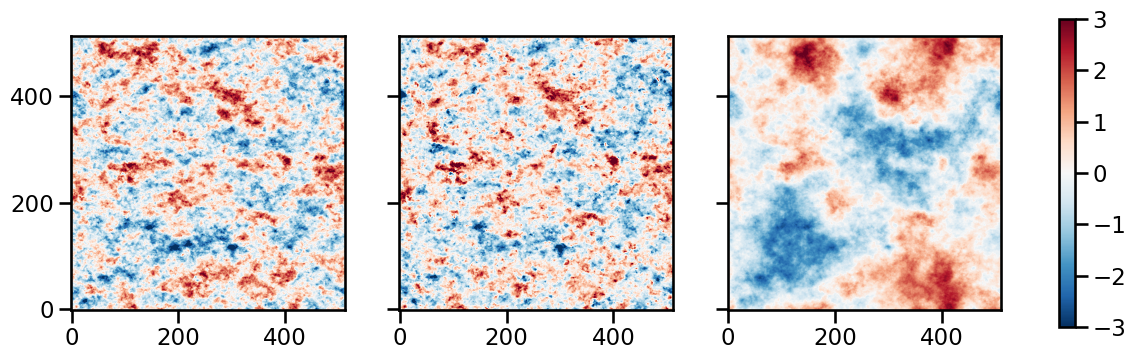

In [20]:
fig, (ax, axx, axxx) = plt.subplots(
    1,
    3,
    sharey=True,
    figsize=(15, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap_, **imshow_kwds)
im = axx.imshow(vmap2_, **imshow_kwds)
im = axxx.imshow(vmap0_, **imshow_kwds)
fig.colorbar(im, ax=[ax, axx, axxx])

In [21]:
print(vmap.var(),vmap0.var(),vmap_.var(),vmap2_.var(),vmap0_.var())

1.0000000000000004 1.0 1.0000000000000002 1.0 1.0


In [22]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 4607.432861804962 seconds ---


# Structure function and Confidence intervals

In [ ]:
sf_ = strucfunc.strucfunc_numba_parallel(vmap_, dlogr=0.05)
sf0_ = strucfunc.strucfunc_numba_parallel(vmap0_, dlogr=0.05)

In [ ]:
sf2_ = strucfunc.strucfunc_numba_parallel(vmap2_, dlogr=0.05)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit

def fit_structure_function(
    data_in,
    N,
    bfunc,
    bplot,
    name='name',
    data='data',
    pc_per_arcsec=1,
    relative_uncertainty=0.07,
    emcee_steps=50000,
    emcee_burn=500,
    emcee_thin=50,
    emcee_workers=16,
):
    """
    Fits a structure function model to the input data and performs MCMC sampling.
    
    Parameters
    ----------
    sf_noise_2 : dict or DataFrame-like
        Must have keys: 'N pairs', 'Unweighted B(r)', 'log10 r'
    N : float
        Box size parameter.
    bfunc : module or object
        Must have attribute bfunc03s (model function).
    bplot : module or object
        Must provide corner_plot and strucfunc_plot functions.
    name : str
        Name identifier for plots.
    data : str
        Data identifier for plots.
    pc_per_arcsec : float
        Conversion factor for arcsec to pc.
    relative_uncertainty : float
        Relative uncertainty for weighting.
    emcee_steps : int
        Number of MCMC steps.
    emcee_burn : int
        Number of MCMC burn-in steps.
    emcee_thin : int
        MCMC thinning factor.
    emcee_workers : int
        Number of parallel workers for emcee.
    
    Returns
    -------
    results : dict
        Contains 'result' (LMFit minimize result) and 'result_emcee' (MCMC result).
    """

    # Mask valid data
    mask     = np.array(data_in["N pairs"]) > 0
    B        = np.array(data_in['Unweighted B(r)'])[mask]
    r        = np.array(10 ** np.array(data_in['log10 r']))[mask]
    box_size = N

    # Model
    model = lmfit.Model(bfunc.bfunc03s)

    # Set parameter hints
    model.set_param_hint("r0",    value=0.1 * box_size,      min=0.01 * box_size,     max=2.0 * box_size)
    model.set_param_hint("sig2",  value=0.5 * B.max(),       min=0.25 * B.max(),      max=2.0 * B.max())
    model.set_param_hint("m",     value=1.0,                 min=0.5,                 max=2.0)
    model.set_param_hint("s0",    value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec)
    model.set_param_hint("noise", value=0.5 * B.min(),       min=0.0, max=3 * B.min())
    # model.set_param_hint("box_size", value=box_size, vary=False)

    # Weights
    weights = 1.0 / (relative_uncertainty * B)
    large_scale = r > 0.5 * box_size
    # Optional: weights[large_scale] /= 1.25
    # Optional: weights[:1] /= 2.0

    to_fit = r <= 0.6 * box_size
    result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

    # MCMC with emcee
    emcee_kws = dict(
        steps=emcee_steps,
        burn=emcee_burn,
        thin=emcee_thin,
        is_weighted=True,
        progress=False,
        workers=emcee_workers,
    )
    emcee_params = result.params.copy()
    # Optionally add lnsigma parameter here if needed

    result_emcee = model.fit(
        data=B[to_fit],
        r=r[to_fit],
        weights=weights[to_fit],
        params=emcee_params,
        method="emcee",
        nan_policy="omit",
        fit_kws=emcee_kws,
    )

    # Plot acceptance fraction
    plt.figure()
    plt.plot(result_emcee.acceptance_fraction, "o")
    plt.xlabel("walker")
    plt.ylabel("acceptance fraction")
    plt.title("MCMC Acceptance Fraction")
    plt.show()

    # Print autocorrelation times
    if hasattr(result_emcee, "acor"):
        print("Autocorrelation time for the parameters:")
        print("----------------------------------------")
        for i, p in enumerate(result_emcee.params):
            try:
                print(f"{p} = {result_emcee.acor[i]:.3f}")
            except IndexError:
                pass

    # Corner plot
    bplot.corner_plot(
        result_emcee, result, name, data, data_ranges=[0.95, 0.99, 0.995, 0.997, 0.999]
    )

    # Structure function plot
    bplot.strucfunc_plot(
        result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
    )

    # Return fit results
    return {'result': result, 'result_emcee': result_emcee}


In [ ]:
fig, ax = plt.subplots(
    figsize=(6, 6),
)
mask = sf_["N pairs"] > 0
r_ = 10 ** sf_["log10 r"][mask]
B_ = sf_["Unweighted B(r)"][mask]
B2_ = sf2_["Unweighted B(r)"][mask]
B0_ = sf0_["Unweighted B(r)"][mask]

ax.plot(r_, B_, marker=".", color = 'b', label = '3D tap')
ax.plot(r_, B2_, marker=".", color = 'g', label = '3D tap 2')
ax.plot(r_, B0_, marker=".", color = 'orange', label = '3D nt')
ax.plot(r, B, marker="x", color = 'b', label = '2D tap')
ax.plot(r, B0, marker="x", color = 'orange', label = '2D nt')

rgrid = np.logspace(0.0, 2.0)

for scale in 0.02, 0.08:
    ax.plot(rgrid, scale * rgrid ** m2D, color="0.8")

ax.axhline(1.0, color="k", linestyle="dotted")
ax.axvline(r0, color="k", linestyle="dotted")
ax.axvline(N / 2, color="k", linestyle="dashed")
ax.axvline(N / 6, color="k", linestyle="dashed")
ax.set(
    xscale="log",
    yscale="log",
    ylim=[8e-3, 4],
)

ax.legend()


In [ ]:
results_ = fit_structure_function(sf_, N, bfunc=bfunc, bplot=bplot, name = 'sf_', data = 'sf_')

In [ ]:
results0_ = fit_structure_function(sf0_, N, bfunc=bfunc, bplot=bplot, name = 'sf0_', data = 'sf0_')

In [ ]:
results = fit_structure_function(sf, N, bfunc=bfunc, bplot=bplot, name = 'sf', data = 'sf')

In [ ]:
results0 = fit_structure_function(sf0, N, bfunc=bfunc, bplot=bplot, name = 'sf0', data = 'sf0')

In [ ]:
results2_ = fit_structure_function(sf2_, N, bfunc=bfunc, bplot=bplot, name = 'sf2_', data = 'sf2_')

# Anaysis results

In [ ]:
res = ci_results_compiler.ci_results_compiler(results)

In [ ]:
res0 = ci_results_compiler.ci_results_compiler(results0)

In [ ]:
res_ = ci_results_compiler.ci_results_compiler(results_)

In [ ]:
res0_ = ci_results_compiler.ci_results_compiler(results0_)

In [ ]:
res2_ = ci_results_compiler.ci_results_compiler(results2_)

In [ ]:
ci_results_compiler.plot_param_comp(res,res0,res_,res2_,res0_, labels=['2D','2D nt','3D','3D-2','3D nt'], decimals=4)


In [ ]:
def plot_param(*dicts, labels=None, decimals=4, true=None):
    """
    For each key in the input dicts, plot the values (with error bars) on a separate plot.
    Optionally plot reference 'true' values as horizontal lines.

    Parameters
    ----------
    *dicts : one or more dict objects
        Each dict must have keys mapping to lists of [value, upper, lower] for error bar plotting.
    labels : list of str, optional
        Labels for each dictionary. If None, will use "Set 1", "Set 2", etc.
    decimals : int, optional
        Number of decimals to round values (default: 4).
    true : list, tuple, or dict, optional
        If list/tuple: reference values for keys ['sig2', 'r0', 'm'] in that order.
        If dict: maps key names to reference values.
    """
    n_sets = len(dicts)
    param_keys = list(dicts[0].keys())
    n_params = len(param_keys)

    # Prepare labels
    if labels is None:
        labels = [f"Set {i+1}" for i in range(n_sets)]

    x = np.arange(n_sets)  # one spot for each set (dict)

    # Prepare "true" as a mapping from param_keys to values
    if true is not None:
        if isinstance(true, dict):
            true_map = true
        elif isinstance(true, (list, tuple)):
            # Map for sig2, r0, m if present
            true_keys = ['sig2', 'r0', 'm']
            true_map = {k: v for k, v in zip(true_keys, true)}
        else:
            true_map = {}
    else:
        true_map = {}

    for key in param_keys:
        values = []
        yerr_upper = []
        yerr_lower = []
        for d in dicts:
            values.append(round(d[key][0], decimals))
            yerr_upper.append(max(0, round(d[key][1], decimals)))
            yerr_lower.append(max(0, round(d[key][2], decimals)))

        plt.figure(figsize=(max(4, n_sets * 1.2), 5))
        plt.errorbar(
            x,
            values,
            yerr=[yerr_lower, yerr_upper],
            fmt='o',
            capsize=5,
            elinewidth=2,
            label=key,
        )
        plt.xticks(x, labels, rotation=30)
        plt.ylabel(key)
        plt.title(f"{key} value with asymmetric uncertainties")
        plt.grid(alpha=0.3)
        # Optionally add value labels on points:
        for xi, val in zip(x, values):
            plt.text(xi, val, f"{val}", ha="center", va="bottom", fontsize=9)
        # Draw "true" value line if provided
        if key in true_map and true_map[key] is not None:
            plt.axhline(true_map[key], color='red', linestyle='--', label='Reference')
            #plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
plot_param(res,res0,res_,res2_,res0_, labels=['2D','2D nt','3D','3D-2','3D nt'], decimals=4, true = [1,32,1])

N = X
ro = N/8